# Poli: JEPA semantic anomaly detection (RPS video)

This notebook loads V-JEPA2, embeds short clips from your RPS video, and detects a semantic change when a new gesture appears.

Steps:
1) Load model
2) Decode video and build clips
3) Embed clips and compute anomaly scores
4) Visualize peaks and patch heatmap

In [2]:
# If you are in Colab, uncomment the next line.
# %pip install -q torch torchvision transformers av numpy matplotlib opencv-python

import os
import numpy as np
import torch
import av
import cv2
import matplotlib.pyplot as plt

from transformers import AutoVideoProcessor, AutoModel

/Users/paolodeidda/miniforge3/lib/python3.12/site-packages/transformers/loss/loss_for_object_detection.py:27: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.optimize import linear_sum_assignment


In [3]:
device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
dtype = torch.float16 if device != "cpu" else torch.float32

hf_repo = "facebook/vjepa2-vitl-fpc64-256"
print("Device:", device)
print("Loading:", hf_repo)

processor = AutoVideoProcessor.from_pretrained(hf_repo)
model = AutoModel.from_pretrained(
    hf_repo,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
).to(device).eval()

print("Model loaded.")

Device: mps
Loading: facebook/vjepa2-vitl-fpc64-256


video_preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

Model loaded.


In [5]:
VIDEO_PATH = "../../assets/rock-paper-scissors.MOV"

def _resize_frame(frame_rgb, max_side=512):
    if max_side is None:
        return frame_rgb
    h, w = frame_rgb.shape[:2]
    scale = max_side / float(max(h, w))
    if scale >= 1.0:
        return frame_rgb
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    return cv2.resize(frame_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

def decode_video(path, stride=1, max_frames=None, max_side=512):
    container = av.open(path)
    stream = container.streams.video[0]
    fps = float(stream.average_rate) if stream.average_rate else 30.0

    frames = []
    for i, frame in enumerate(container.decode(video=0)):
        if i % stride != 0:
            continue
        rgb = frame.to_ndarray(format="rgb24")
        rgb = _resize_frame(rgb, max_side=max_side)
        frames.append(rgb)
        if max_frames and len(frames) >= max_frames:
            break

    container.close()
    frames = np.stack(frames, axis=0)
    return frames, fps

frames, fps = decode_video(VIDEO_PATH, stride=1, max_frames=None, max_side=512)
print("Frames:", frames.shape, "FPS:", fps)

Frames: (2710, 288, 512, 3) FPS: 60.0


In [7]:
CLIP_LEN = 16
CLIP_STRIDE = 8

def make_clips(frames, fps, clip_len=CLIP_LEN, stride=CLIP_STRIDE):
    clips = []
    times = []
    for start in range(0, len(frames) - clip_len + 1, stride):
        clip = frames[start:start + clip_len]
        clips.append(clip)
        times.append((start + clip_len / 2) / fps)
    return clips, np.array(times)

clips, times = make_clips(frames, fps)
print("Num clips:", len(clips))
print("Time span:", float(times[0]), "->", float(times[-1]))

Num clips: 337
Time span: 0.13333333333333333 -> 44.93333333333333


In [8]:
def embed_clips(clips, batch=4):
    Z = []
    with torch.no_grad():
        for i in range(0, len(clips), batch):
            batch_clips = clips[i:i + batch]
            inputs = processor(batch_clips, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            z = model.get_vision_features(**inputs).mean(dim=1)
            Z.append(z.cpu().numpy())
    Z = np.concatenate(Z, axis=0)
    Z = Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), 1e-8, None)
    return Z

Z = embed_clips(clips, batch=4)
print("Embeddings:", Z.shape)

Embeddings: (337, 1024)


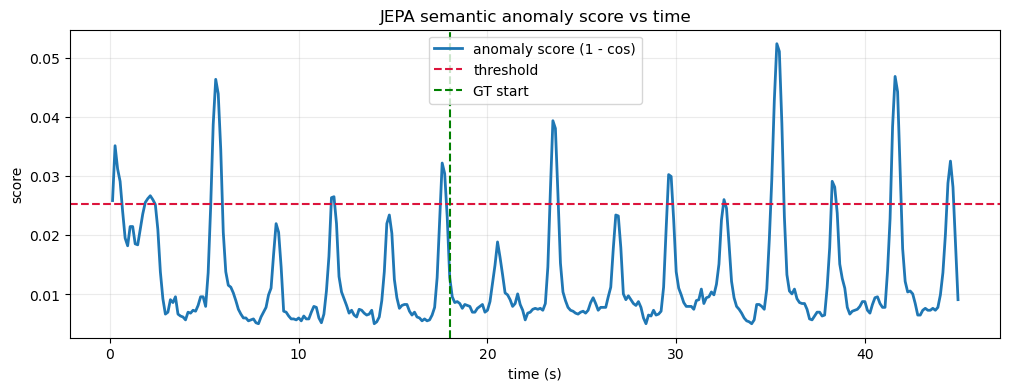

Top anomaly times (s): [35.33333333 35.46666667 41.6         5.6        41.73333333]


In [9]:
BASELINE_SEC = 10.0
METHOD = "proto"  # "proto" or "knn"
K_NEIGHBORS = 5
SMOOTH = 3

def compute_scores(Z, times, baseline_sec, method="proto", k=5, smooth=1):
    baseline_mask = times <= baseline_sec
    if baseline_mask.sum() < 3:
        raise ValueError("Baseline too short. Increase BASELINE_SEC.")

    base = Z[baseline_mask]
    if method == "proto":
        proto = base.mean(axis=0)
        proto = proto / np.clip(np.linalg.norm(proto), 1e-8, None)
        scores = 1.0 - (Z @ proto)
    elif method == "knn":
        sim = Z @ base.T
        k = min(k, base.shape[0])
        topk = np.partition(sim, -k, axis=1)[:, -k:]
        scores = 1.0 - topk.mean(axis=1)
    else:
        raise ValueError("Unknown method: " + str(method))

    if smooth and smooth > 1:
        kernel = np.ones(smooth, dtype=np.float32) / float(smooth)
        scores = np.convolve(scores, kernel, mode="same")
    return scores, baseline_mask

scores, baseline_mask = compute_scores(Z, times, BASELINE_SEC, METHOD, K_NEIGHBORS, SMOOTH)

med = np.median(scores[baseline_mask])
mad = np.median(np.abs(scores[baseline_mask] - med)) + 1e-8
threshold = med + 4.0 * mad

GT_START_SEC = 18.0  # set this to when the new gesture starts

plt.figure(figsize=(12, 4))
plt.plot(times, scores, lw=2, label="anomaly score (1 - cos)")
plt.axhline(threshold, color="crimson", linestyle="--", label="threshold")
plt.axvline(GT_START_SEC, color="green", linestyle="--", label="GT start")
plt.xlabel("time (s)")
plt.ylabel("score")
plt.title("JEPA semantic anomaly score vs time")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print("Top anomaly times (s):", times[np.argsort(-scores)[:5]])

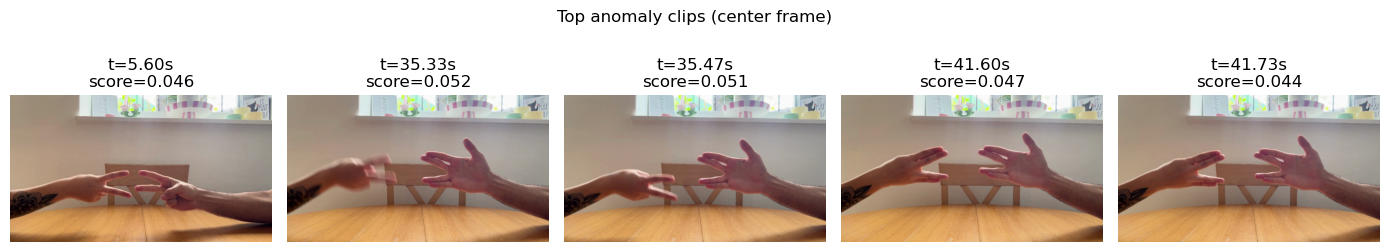

In [10]:
topk = 5
top_idx = np.argsort(-scores)[:topk]
top_idx = sorted(top_idx)

plt.figure(figsize=(14, 3))
for j, idx in enumerate(top_idx, start=1):
    frame = clips[idx][CLIP_LEN // 2]
    ax = plt.subplot(1, topk, j)
    ax.imshow(frame)
    ax.set_title(f"t={times[idx]:.2f}s\nscore={scores[idx]:.3f}")
    ax.axis("off")
plt.suptitle("Top anomaly clips (center frame)")
plt.tight_layout()
plt.show()

In [11]:
def patch_heatmap_for_clip(clip, frame_idx=0):
    inputs = processor(clip, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model(**inputs)

    if not hasattr(out, "last_hidden_state"):
        raise RuntimeError("Model output missing last_hidden_state")

    tokens = out.last_hidden_state
    cls = tokens[:, 0, :]
    patch = tokens[:, 1:, :]

    cfg = model.config
    patch_size = getattr(cfg, "patch_size", 16)
    tubelet_size = getattr(cfg, "tubelet_size", 2)
    image_size = getattr(cfg, "image_size", 224)

    t = clip.shape[0] // tubelet_size
    h = image_size // patch_size
    w = image_size // patch_size
    expected = t * h * w

    if patch.shape[1] != expected:
        print("Patch shape mismatch:", patch.shape, "expected:", expected)
        return None

    patch = patch.reshape(1, t, h, w, -1)[0]
    t_idx = min(t - 1, frame_idx // tubelet_size)
    p = patch[t_idx]

    p_norm = p / (torch.norm(p, dim=-1, keepdim=True) + 1e-8)
    cls_norm = cls[0] / (torch.norm(cls[0]) + 1e-8)
    sim = (p_norm * cls_norm).sum(dim=-1).cpu().numpy()

    heat = cv2.resize(sim, (clip.shape[2], clip.shape[1]), interpolation=cv2.INTER_CUBIC)
    return heat

idx = int(np.argmax(scores))
heat = patch_heatmap_for_clip(clips[idx], frame_idx=CLIP_LEN // 2)

if heat is not None:
    frame = clips[idx][CLIP_LEN // 2]
    plt.figure(figsize=(6, 4))
    plt.imshow(frame)
    plt.imshow(heat, cmap="jet", alpha=0.45)
    plt.title(f"Patch heatmap (t={times[idx]:.2f}s)")
    plt.axis("off")
    plt.show()

Patch shape mismatch: torch.Size([1, 2047, 1024]) expected: 2048
